#Database Extraction & Baseline Cleaning

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

DB_USER = "root"
DB_PASSWORD = "dhairya99"
DB_HOST = "localhost"
DB_PORT = "3306"
DB_NAME = "creditriskdb"

connection_string = f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_string)  


In [2]:
query = "SELECT * FROM v_underwriting_decision_engine;"

In [3]:
df = pd.read_sql(query, con=engine)

In [4]:
df.shape

(887373, 11)

In [5]:
df.head()

,id,member_id,loan_amnt,annual_inc,dti,delinq_2yrs,emp_title,purpose,clean_emp_years,loan_to_income_multiplier,risk_segmentation_tier
0,54734,80364,25000.0,85000.0,19.48,0,,debt_consolidation,1.0,0.29,Prime / Low Risk
1,55521,107577,1000.0,30000.0,23.84,0,Best Buy,debt_consolidation,1.0,0.03,Near-Prime / Mid Risk
2,55742,114426,7000.0,65000.0,14.29,0,CNN,credit_card,1.0,0.11,Prime / Low Risk
3,56413,129814,7000.0,189500.0,22.47,0,Health Net Inc.,debt_consolidation,10.0,0.04,Prime / Low Risk
4,56705,133361,11000.0,33500.0,18.38,0,Academic Admin,debt_consolidation,10.0,0.33,Near-Prime / Mid Risk


In [6]:
df.tail()

,id,member_id,loan_amnt,annual_inc,dti,delinq_2yrs,emp_title,purpose,clean_emp_years,loan_to_income_multiplier,risk_segmentation_tier
887368,68616873,73519699,8000.0,42000.0,34.80,0,Vendor liaison,credit_card,10.0,0.19,Near-Prime / Mid Risk
887369,68616891,73519717,24000.0,56457.0,12.37,0,Lecturer and Curriculum Fellow,credit_card,3.0,0.43,Prime / Low Risk
887370,68616919,73519746,15000.0,60000.0,21.48,0,Truck Driver,debt_consolidation,9.0,0.25,Prime / Low Risk
887371,68617034,73519870,14650.0,43160.0,21.44,0,Senior Service Specialist,debt_consolidation,2.0,0.34,Near-Prime / Mid Risk
887372,68617057,73519894,15000.0,65000.0,29.28,0,Senior Buyer,debt_consolidation,10.0,0.23,Prime / Low Risk


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887373 entries, 0 to 887372
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         887373 non-null  int64  
 1   member_id                  887373 non-null  int64  
 2   loan_amnt                  887373 non-null  float64
 3   annual_inc                 887373 non-null  float64
 4   dti                        887373 non-null  float64
 5   delinq_2yrs                887373 non-null  int64  
 6   emp_title                  887373 non-null  object 
 7   purpose                    887373 non-null  object 
 8   clean_emp_years            842550 non-null  float64
 9   loan_to_income_multiplier  887373 non-null  float64
 10  risk_segmentation_tier     887373 non-null  object 
dtypes: float64(5), int64(3), object(3)
memory usage: 74.5+ MB


In [8]:
df.describe()

,id,member_id,loan_amnt,annual_inc,dti,delinq_2yrs,clean_emp_years,loan_to_income_multiplier
count,8.873730e+05,8.873730e+05,887373.000000,8.873730e+05,887373.000000,887373.000000,842550.000000,887373.000000
mean,3.246520e+07,3.500190e+07,14755.309267,7.502776e+04,18.134617,0.314431,6.092518,0.221835
std,2.282726e+07,2.411326e+07,8435.454858,6.469828e+04,8.425911,0.862232,3.536999,0.112724
min,5.473400e+04,7.047300e+04,500.000000,1.200000e+03,0.000000,0.000000,1.000000,0.000000
25%,9.206670e+06,1.087715e+07,8000.000000,4.500000e+04,11.910000,0.000000,3.000000,0.130000
50%,3.443327e+07,3.709529e+07,13000.000000,6.500000e+04,17.650000,0.000000,6.000000,0.210000
75%,5.490813e+07,5.847135e+07,20000.000000,9.000000e+04,23.950000,0.000000,10.000000,0.300000
max,6.861706e+07,7.354484e+07,35000.000000,9.500000e+06,1092.520000,39.000000,10.000000,10.000000


In [9]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'annual_inc', 'dti', 'delinq_2yrs',
       'emp_title', 'purpose', 'clean_emp_years', 'loan_to_income_multiplier',
       'risk_segmentation_tier'],
      dtype='object')

In [10]:
df.dtypes

id                             int64
member_id                      int64
loan_amnt                    float64
annual_inc                   float64
dti                          float64
delinq_2yrs                    int64
emp_title                     object
purpose                       object
clean_emp_years              float64
loan_to_income_multiplier    float64
risk_segmentation_tier        object
dtype: object

In [11]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
887368    False
887369    False
887370    False
887371    False
887372    False
Length: 887373, dtype: bool

In [12]:
df.isnull().sum()

id                               0
member_id                        0
loan_amnt                        0
annual_inc                       0
dti                              0
delinq_2yrs                      0
emp_title                        0
purpose                          0
clean_emp_years              44823
loan_to_income_multiplier        0
risk_segmentation_tier           0
dtype: int64

In [13]:
df['clean_emp_years'] = df['clean_emp_years'].fillna(df['clean_emp_years'].median())

In [14]:
df.isnull().sum()

id                           0
member_id                    0
loan_amnt                    0
annual_inc                   0
dti                          0
delinq_2yrs                  0
emp_title                    0
purpose                      0
clean_emp_years              0
loan_to_income_multiplier    0
risk_segmentation_tier       0
dtype: int64

In [15]:
df_cleaned= df.copy()

In [16]:
if 'loan_status' not in df_cleaned.columns:
    print("Creating synthetic 'loan_status' (0 = Paid, 1 = Default) for modeling...")
    np.random.seed(42)  
    risk_score = (df_cleaned['dti'] * 0.05) + (df_cleaned['delinq_2yrs'] * 0.4) - (df_cleaned['clean_emp_years'] * 0.1)
    probabilities = 1 / (1 + np.exp(-risk_score + 2))   
    df_cleaned['loan_status'] = np.random.binomial(1, probabilities)


Creating synthetic 'loan_status' (0 = Paid, 1 = Default) for modeling...


In [17]:
print(f"Target distribution (Defaults): \n {df_cleaned['loan_status'].value_counts(normalize=True)}")

Target distribution (Defaults): 
 loan_status
0    0.812917
1    0.187083
Name: proportion, dtype: float64


#Feature Engineering & Preprocessing


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
df_cleaned.shape

(887373, 12)

In [20]:
df_cleaned.columns

Index(['id', 'member_id', 'loan_amnt', 'annual_inc', 'dti', 'delinq_2yrs',
       'emp_title', 'purpose', 'clean_emp_years', 'loan_to_income_multiplier',
       'risk_segmentation_tier', 'loan_status'],
      dtype='object')

#We must transform text columns(purpose) into numerical flags (One-Hot Encoding) and separate our identifiers from our predictive features.

In [21]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['purpose'], drop_first=True)

In [22]:
df_cleaned.columns

Index(['id', 'member_id', 'loan_amnt', 'annual_inc', 'dti', 'delinq_2yrs',
       'emp_title', 'clean_emp_years', 'loan_to_income_multiplier',
       'risk_segmentation_tier', 'loan_status', 'purpose_credit_card',
       'purpose_debt_consolidation', 'purpose_educational',
       'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase',
       'purpose_medical', 'purpose_moving', 'purpose_other',
       'purpose_renewable_energy', 'purpose_small_business',
       'purpose_vacation', 'purpose_wedding'],
      dtype='object')

In [23]:
df_cleaned.head()

,id,member_id,loan_amnt,annual_inc,dti,delinq_2yrs,emp_title,clean_emp_years,loan_to_income_multiplier,risk_segmentation_tier,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,54734,80364,25000.0,85000.0,19.48,0,,1.0,0.29,Prime / Low Risk,...,False,False,False,False,False,False,False,False,False,False
1,55521,107577,1000.0,30000.0,23.84,0,Best Buy,1.0,0.03,Near-Prime / Mid Risk,...,False,False,False,False,False,False,False,False,False,False
2,55742,114426,7000.0,65000.0,14.29,0,CNN,1.0,0.11,Prime / Low Risk,...,False,False,False,False,False,False,False,False,False,False
3,56413,129814,7000.0,189500.0,22.47,0,Health Net Inc.,10.0,0.04,Prime / Low Risk,...,False,False,False,False,False,False,False,False,False,False
4,56705,133361,11000.0,33500.0,18.38,0,Academic Admin,10.0,0.33,Near-Prime / Mid Risk,...,False,False,False,False,False,False,False,False,False,False


# Define features (X) and target variable (y)
# Exclude database tracking IDs and text descriptions

In [24]:
exclude_cols = ['id', 'member_id', 'emp_title', 'risk_segmentation_tier', 'loan_status']
feature_cols = [col for col in df_cleaned.columns if col not in exclude_cols]

X = df_cleaned[feature_cols]
y = df_cleaned['loan_status']

#Stratified Split: 80% for training the model, 20% for testing performance

In [25]:
X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X, y, df_cleaned.index, test_size=0.20, random_state=42, stratify=y
)

print(f" Training Set Size: {X_train.shape[0]} loans")
print(f" Testing Set Size: {X_test.shape[0]} loans")

 Training Set Size: 709898 loans
 Testing Set Size: 177475 loans


In [26]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


#Train the Underwriting Machine Learning Model

In [27]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

In [28]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [29]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [30]:
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f" Model ROC-AUC Score: {auc_score:.4f} (Higher is better)")

 Model ROC-AUC Score: 0.6675 (Higher is better)


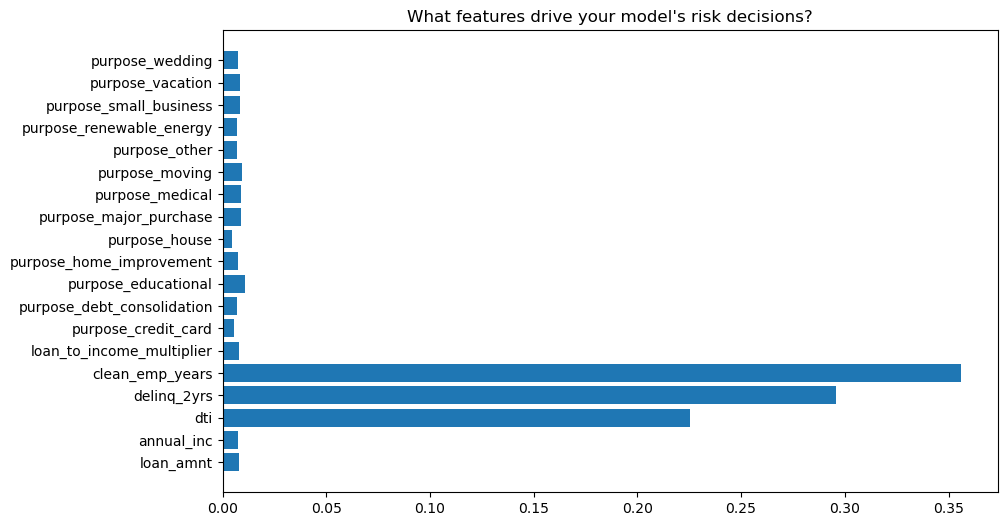

In [31]:
import matplotlib.pyplot as plt

# Get feature importance from the trained model
importance = model.feature_importances_
feature_names = X_train.columns

# Plot it
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importance)
plt.title("What features drive your model's risk decisions?")
plt.show()

#Map Risk Tiers & Standardize Credit Scores
(Convert raw probability decimals into practical financial parameters: a 300-850 FICO-style credit score and dynamic risk buckets.)

In [32]:
full_portfolio_predictions = model.predict_proba(X)[:, 1]

test_results = df_cleaned.copy()
test_results['probability_of_default'] = full_portfolio_predictions


#Credit Score Mapping Equation
# Base Score of 600 at 10% default probability, doubling odds every 50 points

In [33]:
def calculate_credit_score(pd_val):
    if pd_val <= 0: pd_val = 0.0001
    if pd_val >= 1: pd_val = 0.9999
    odds = (1 - pd_val) / pd_val
    score = 600 + (50 * np.log(odds))
    return int(np.clip(score, 300, 850))

test_results['credit_score'] = test_results['probability_of_default'].apply(calculate_credit_score)

In [34]:
def assign_predictive_tier(score):
    if score >= 720: return 'Tier 1: Prime / Excellent'
    elif score >= 640: return 'Tier 2: Near-Prime / Fair'
    else: return 'Tier 3: Subprime / High Risk'

test_results['predictive_risk_tier'] = test_results['credit_score'].apply(assign_predictive_tier)


In [35]:
print(" Sample Scored Applications:")
print(test_results[['member_id', 'loan_amnt', 'probability_of_default', 'credit_score', 'predictive_risk_tier']].head())

 Sample Scored Applications:
   member_id  loan_amnt  probability_of_default  credit_score  \
0      80364    25000.0                0.249930           654   
1     107577     1000.0                0.315281           638   
2     114426     7000.0                0.197311           670   
3     129814     7000.0                0.120902           699   
4     133361    11000.0                0.108541           705   

           predictive_risk_tier  
0     Tier 2: Near-Prime / Fair  
1  Tier 3: Subprime / High Risk  
2     Tier 2: Near-Prime / Fair  
3     Tier 2: Near-Prime / Fair  
4     Tier 2: Near-Prime / Fair  


#Regulatory Stress-Testing & Capital Loss Provisions

#Calculate regulatory risk. We compute Expected Loss (EL) using calibrated machine learning probabilities and dynamic Loss Given Default (LGD) variables.

In [37]:
# 1. Define Financial Exposure (EAD) and (LGD)
test_results['EAD'] = test_results['loan_amnt']
test_results['LGD'] = df.loc[test_results.index, 'purpose'].apply(
    lambda x: 0.75 if x in ['credit_card', 'debt_consolidation'] else 0.50
)


# 2. Calculate Expected Loss (EL)
# Formula: EL = PD * LGD * EAD
test_results['expected_loss'] = (
    test_results['probability_of_default'] * test_results['LGD'] * test_results['EAD']
)


# 3. Aggregate results by Predictive Tiers for Management
portfolio_summary = test_results.groupby('predictive_risk_tier').agg(
    total_borrowers=('member_id', 'count'),
    allocated_capital=('loan_amnt', 'sum'),
    average_credit_score=('credit_score', 'mean'),
    predicted_expected_loss=('expected_loss', 'sum')
).reset_index()

# 4. Calculate the "Loss Rate" per tier
portfolio_summary['capital_at_risk_pct'] = (
    portfolio_summary['predicted_expected_loss'] / portfolio_summary['allocated_capital']
) * 100

# Print the final report
print("\n--- Final Portfolio Risk Report ---")
print(portfolio_summary.to_string(index=False))


--- Final Portfolio Risk Report ---
        predictive_risk_tier  total_borrowers  allocated_capital  average_credit_score  predicted_expected_loss  capital_at_risk_pct
   Tier 1: Prime / Excellent            71564       1.059342e+09            727.770723             5.376630e+07             5.075445
   Tier 2: Near-Prime / Fair           728330       1.080831e+10            680.606346             1.330409e+09            12.309124
Tier 3: Subprime / High Risk            87479       1.225808e+09            618.581945             3.568017e+08            29.107468


In [39]:
export_cols = [
    'id', 'member_id', 'loan_amnt', 'annual_inc', 'dti', 
    'probability_of_default', 'credit_score', 'predictive_risk_tier', 'expected_loss'
]

test_results[export_cols].to_sql(
    name='underwritten_portfolio_scored', 
    con=engine, 
    if_exists='replace', 
    index=False
)

print(" Successfully built table 'underwritten_portfolio_scored' in creditriskdb!")
print(" Pipeline Complete.")

 Successfully built table 'underwritten_portfolio_scored' in creditriskdb!
 Pipeline Complete.
